In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [5]:
# 1. データの簡易ロードと前処理 (MovieLens small)
# 本来は ratings.csv を使って学習しますが、ここでは予測スコアと特徴量が既にあると仮定
n_movies = 50
np.random.seed(42)

In [6]:
# 映画の潜在特徴量 (埋め込みベクトル) を模倣
movie_embeddings = np.random.randn(n_movies, 10) 
# 各映画の予測スコア (ユーザーの好み)
scores = np.linspace(0.9, 0.1, n_movies) + np.random.normal(0, 0.05, n_movies)

In [7]:

# 2. カーネル行列の構築
# 類似度 S (Cosine Similarity)
S = cosine_similarity(movie_embeddings)
S = (S + 1) / 2  # [0, 1] に正規化

In [8]:
def dpp_greedy_map(L, k):
    """Fast Greedy MAP Inference (Chen et al. 2018)"""
    selected = []
    candidates = list(range(len(L)))
    
    # 逐次的に行列式を最大化する要素を選択
    for _ in range(k):
        best_gain = -1
        best_idx = -1
        for c in candidates:
            current_set = selected + [c]
            # 行列式の値を計算 (実際には Cholesky 更新で高速化可能)
            gain = np.linalg.det(L[np.ix_(current_set, current_set)])
            if gain > best_gain:
                best_gain = gain
                best_idx = c
        if best_idx == -1: break
        selected.append(best_idx)
        candidates.remove(best_idx)
    return selected

In [9]:
# 3. トレードオフのシミュレーション
alphas = [0.1, 0.5, 1.0, 2.0, 5.0] # 精度への注力度
results = []
for alpha in alphas:
    q = np.exp(alpha * scores)
    L = np.outer(q, q) * S
    
    indices = dpp_greedy_map(L, k=10)
    
    avg_score = np.mean(scores[indices]) # 精度指標
    # 多様性指標: 選択されたアイテム間の平均距離 (1 - similarity)
    avg_dist = 1 - (np.sum(S[np.ix_(indices, indices)]) - 10) / (10 * 9)
    
    results.append((alpha, avg_score, avg_dist))

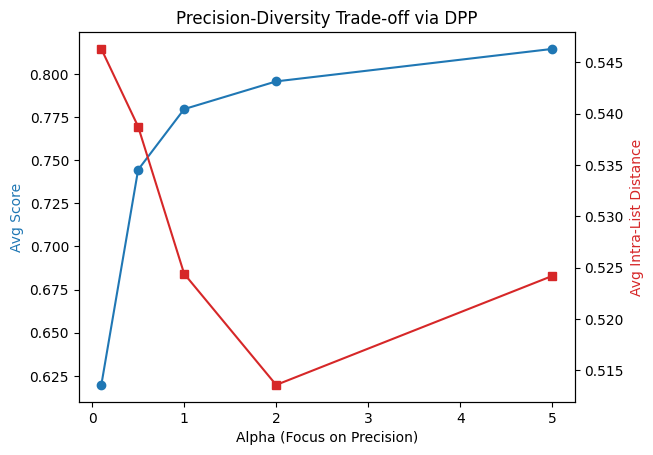

In [10]:
# 4. 可視化
res_df = pd.DataFrame(results, columns=['alpha', 'Precision (Score)', 'Diversity (Dist)'])
fig, ax1 = plt.subplots()

ax1.set_xlabel('Alpha (Focus on Precision)')
ax1.set_ylabel('Avg Score', color='tab:blue')
ax1.plot(res_df['alpha'], res_df['Precision (Score)'], marker='o', color='tab:blue', label='Precision')

ax2 = ax1.twinx()
ax2.set_ylabel('Avg Intra-List Distance', color='tab:red')
ax2.plot(res_df['alpha'], res_df['Diversity (Dist)'], marker='s', color='tab:red', label='Diversity')

plt.title("Precision-Diversity Trade-off via DPP")
plt.show()